# KAN-AD + DeepSVDD Hybrid on SWaT with Alpha Tuning and EasyTSAD Evaluation

This notebook rebuilds the hybrid model in a cleaner and safer way.

## What is fixed compared with the previous version
- **Alpha is not tuned on EasyTSAD's default validation split**, because for SWaT that split is often normal-only.
- We create a **custom holdout dataset**:
  - original SWaT **train** stays as train
  - the **first anomalous part of the original test** is used as a **calibration split** for alpha tuning
  - the **remaining test tail** becomes the final EasyTSAD test set
- The final anomaly score is:

\[
s_t = \alpha \cdot \sigma(z(E_t)) + (1-\alpha) \cdot \sigma(z(D_t))
\]

where:
- \(E_t\): prediction error
- \(D_t\): DeepSVDD distance
- \(z(\cdot)\): z-score using **train-only** statistics
- \(\sigma\): sigmoid

## Final workflow
1. Install repos and EasyTSAD
2. Build a custom SWaT holdout dataset on disk
3. Train the hybrid model
4. Tune **alpha** on the calibration split
5. Run final evaluation on the holdout test split with EasyTSAD

In [1]:

# Cell 1 — Install dependencies and clone repositories

!pip install --upgrade pip
!pip install torch torchinfo tqdm numpy scikit-learn matplotlib pandas toml

!rm -rf /content/KAN-AD
!rm -rf /content/datasets

!git clone https://github.com/CSTCloudOps/KAN-AD.git /content/KAN-AD
!git clone https://github.com/CSTCloudOps/datasets.git /content/datasets

!rm -rf /content/KAN-AD/datasets
!mv /content/datasets /content/KAN-AD/datasets

%cd /content/KAN-AD

Cloning into '/content/KAN-AD'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 61.77 KiB | 3.43 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Cloning into '/content/datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 22.14 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
/content/KAN-AD


In [2]:

# Cell 2 — Install EasyTSAD, fix import syntax issue, and configure paths

!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git
!sed -i 's/TSData,*/TSData/g' /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py || true
!grep -n "TSData" /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py | head -n 20

import os
import sys
import glob

REPO_ROOT = "/content/KAN-AD"
DATA_ROOT = "/content/KAN-AD/datasets"

sys.path.insert(0, REPO_ROOT)

candidates = glob.glob("/content/KAN-AD/**/kanad/kanad.py", recursive=True)
print("Found KAN-AD candidates:", candidates)
assert candidates, "Could not find kanad/kanad.py inside the cloned KAN-AD repo."

KANAD_PY = sorted(candidates, key=len)[0]
KANAD_PKG_DIR = os.path.dirname(KANAD_PY)
KANAD_ROOT_DIR = os.path.dirname(KANAD_PKG_DIR)

sys.path.insert(0, KANAD_ROOT_DIR)

print("KANAD_PKG_DIR =", KANAD_PKG_DIR)
print("KANAD_ROOT_DIR =", KANAD_ROOT_DIR)
print("sys.path[:4] =", sys.path[:4])

  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-ogb2n8r2
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-ogb2n8r2
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit 10f5e7a4b27f4a326961bb8a77176aac7f6d7cc1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
1:from .TSData import TSData
2:from .MTSData import MTSData
Found KAN-AD candidates: ['/content/KAN-AD/kanad/kanad.py']
KANAD_PKG_DIR = /content/KAN-AD/kanad
KANAD_ROOT_DIR = /content/KAN-AD
sys.path[:4] = ['/content/KAN-AD', '/content/KAN-AD', '/content', '/env/python']


In [3]:

# Cell 3 — Imports and sanity check

import json
import math
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import Dataset, DataLoader

from EasyTSAD.Controller import TSADController
from EasyTSAD.DataFactory import TSData
from EasyTSAD.Methods import BaseMethod
from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

from kanad import KANAD
from kanad.kanad import KANADModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("KANAD imported:", KANAD)
print("KANADModel imported:", KANADModel)
print("TSADController imported:", TSADController)

Device: cuda
KANAD imported: <class 'kanad.kanad.KANAD'>
KANADModel imported: <class 'kanad.kanad.KANADModel'>
TSADController imported: <class 'EasyTSAD.Controller.TSADController.TSADController'>


In [4]:

# Cell 4 — Patch KANADModel helpers used by the hybrid model

def forward_feature(self, x: torch.Tensor):
    res = []
    res.append(x.unsqueeze(1))

    ff = torch.cat(
        [self.orders.repeat(x.size(0), 1, 1)]
        + [torch.cos(order * x.unsqueeze(1)) for order in range(1, self.order + 1)]
        + [x.unsqueeze(1)],
        dim=1,
    )

    res.append(ff)
    ff = self.init_conv(ff)
    ff = self.bn1(ff)
    ff = self.act(ff)

    ff = self.inner_conv(ff) + res.pop()
    ff = self.bn2(ff)
    ff = self.act(ff)

    ff = self.out_conv(ff) + res.pop()
    ff = self.bn3(ff)
    ff = self.act(ff)

    return ff


def forward_head(self, ff: torch.Tensor):
    out = self.final_conv(ff)
    if out.ndim == 3:
        out = out.squeeze(-1)
    return out.squeeze(1)


if not hasattr(KANADModel, "forward_feature"):
    KANADModel.forward_feature = forward_feature

if not hasattr(KANADModel, "forward_head"):
    KANADModel.forward_head = forward_head

print("KANADModel patched with forward_feature() and forward_head().")

KANADModel patched with forward_feature() and forward_head().


In [5]:
# Cell 5 — Build MSL holdout dataset + save calibration arrays outside EasyTSAD tree

import os
import shutil
import numpy as np

# -----------------------------
# Basic paths / names
# -----------------------------
ROOT_DIR = "/content/KAN-AD"
DATA_ROOT = os.path.join(ROOT_DIR, "datasets", "MTS")

ORIG_DATASET = "MSL"
CUSTOM_DATASET = "MSL_HybridHoldout"

orig_curve_dir = os.path.join(DATA_ROOT, ORIG_DATASET, "AllInOne")
custom_dataset_dir = os.path.join(DATA_ROOT, CUSTOM_DATASET)
custom_curve_dir = os.path.join(custom_dataset_dir, "AllInOne")

print("Original MSL curve dir:", orig_curve_dir)

# -----------------------------
# Load original MSL arrays
# -----------------------------
train = np.load(os.path.join(orig_curve_dir, "train.npy"))
test = np.load(os.path.join(orig_curve_dir, "test.npy"))
test_label = np.load(os.path.join(orig_curve_dir, "test_label.npy"))

# MSL has no train labels
train_label = np.zeros(len(train), dtype=np.int64)

print("train shape:", train.shape)
print("test shape :", test.shape)
print("test_label positives:", int(test_label.sum()))

# -----------------------------
# Calibration split
# -----------------------------
test_len = len(test)
default_calib_end = int(0.20 * test_len)

positive_idx = np.where(test_label > 0)[0]
if len(positive_idx) == 0:
    raise ValueError("MSL test labels contain no anomalies.")

last_pos = int(positive_idx[min(len(positive_idx) - 1, max(0, int(0.10 * len(positive_idx))))])

calib_end = max(default_calib_end, last_pos + 1)
calib_end = min(calib_end, test_len - 1)

calib_arr = test[:calib_end].copy()
calib_label = test_label[:calib_end].copy()

final_test = test[calib_end:].copy()
final_test_label = test_label[calib_end:].copy()

print("\nChosen calibration end index:", calib_end)
print("Calibration shape:", calib_arr.shape, " positives:", int(calib_label.sum()))
print("Final test shape :", final_test.shape, " positives:", int(final_test_label.sum()))

# -----------------------------
# Build dataset
# -----------------------------
if os.path.exists(custom_dataset_dir):
    shutil.rmtree(custom_dataset_dir)

os.makedirs(custom_curve_dir, exist_ok=True)

np.save(os.path.join(custom_curve_dir, "train.npy"), train)
np.save(os.path.join(custom_curve_dir, "train_label.npy"), train_label)
np.save(os.path.join(custom_curve_dir, "test.npy"), final_test)
np.save(os.path.join(custom_curve_dir, "test_label.npy"), final_test_label)

# IMPORTANT: copy metadata (required by EasyTSAD)
for extra_name in ["info.json", "meta.json"]:
    src = os.path.join(orig_curve_dir, extra_name)
    dst = os.path.join(custom_curve_dir, extra_name)
    if os.path.exists(src):
        shutil.copy2(src, dst)

# -----------------------------
# Save calibration arrays
# -----------------------------
RUNTIME_DIR = os.path.join(ROOT_DIR, "kanad_runtime")
os.makedirs(RUNTIME_DIR, exist_ok=True)

CALIB_DIR = os.path.join(RUNTIME_DIR, f"{CUSTOM_DATASET}_calibration")
if os.path.exists(CALIB_DIR):
    shutil.rmtree(CALIB_DIR)
os.makedirs(CALIB_DIR, exist_ok=True)

np.save(os.path.join(CALIB_DIR, "calib.npy"), calib_arr)
np.save(os.path.join(CALIB_DIR, "calib_label.npy"), calib_label)

# -----------------------------
# Sanity checks
# -----------------------------
print("\nCreated EasyTSAD dataset at:", custom_curve_dir)
print("Saved files:", sorted(os.listdir(custom_curve_dir)))

print("\nCalibration dir:", CALIB_DIR)
print("Calibration files:", sorted(os.listdir(CALIB_DIR)))

assert os.path.exists(os.path.join(custom_curve_dir, "train.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test_label.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "info.json"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib_label.npy"))

print("\nCell 5 completed successfully.")

Original MSL curve dir: /content/KAN-AD/datasets/MTS/MSL/AllInOne
train shape: (58317, 55)
test shape : (73729, 55)
test_label positives: 7766

Chosen calibration end index: 14745
Calibration shape: (14745, 55)  positives: 2034
Final test shape : (58984, 55)  positives: 5732

Created EasyTSAD dataset at: /content/KAN-AD/datasets/MTS/MSL_HybridHoldout/AllInOne
Saved files: ['info.json', 'test.npy', 'test_label.npy', 'train.npy', 'train_label.npy']

Calibration dir: /content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration
Calibration files: ['calib.npy', 'calib_label.npy']

Cell 5 completed successfully.


In [6]:

# Cell 6 — Utility functions: segmentation, calibration F1 search, normalization, plotting

def contiguous_segments(binary_labels: np.ndarray):
    y = np.asarray(binary_labels).astype(int)
    segs = []
    start = None
    for i, v in enumerate(y):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            segs.append((start, i - 1))
            start = None
    if start is not None:
        segs.append((start, len(y) - 1))
    return segs


def segment_overlap(a, b):
    return not (a[1] < b[0] or b[1] < a[0])


def event_f1_from_binary(pred_binary: np.ndarray, true_binary: np.ndarray):
    gt_segs = contiguous_segments(true_binary)
    pr_segs = contiguous_segments(pred_binary)

    if len(gt_segs) == 0 and len(pr_segs) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_segs) == 0:
        return 0.0, 0.0, 0.0
    if len(pr_segs) == 0:
        return 0.0, 0.0, 0.0

    used_pr = set()
    tp = 0
    for gt in gt_segs:
        for j, pr in enumerate(pr_segs):
            if j in used_pr:
                continue
            if segment_overlap(gt, pr):
                tp += 1
                used_pr.add(j)
                break

    precision = tp / max(len(pr_segs), 1)
    recall = tp / max(len(gt_segs), 1)
    f1 = 0.0 if (precision + recall == 0) else 2 * precision * recall / (precision + recall)
    return f1, precision, recall


def best_event_f1_threshold(scores: np.ndarray, labels: np.ndarray, n_grid: int = 200):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(int)

    if labels.sum() == 0:
        return 0.0, float(np.max(scores)), 0.0, 0.0

    lo = float(np.min(scores))
    hi = float(np.max(scores))

    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError("Non-finite scores encountered during threshold search.")

    if hi <= lo:
        pred = (scores > lo).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        return f1, lo, p, r

    thresholds = np.linspace(lo, hi, n_grid)
    best = (-1.0, lo, 0.0, 0.0)

    for thr in thresholds:
        pred = (scores > thr).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        if f1 > best[0]:
            best = (f1, float(thr), float(p), float(r))

    return best


def sigmoid_np(x):
    x = np.clip(x, -8.0, 8.0)
    return 1.0 / (1.0 + np.exp(-x))


def zscore_sigmoid(x, mu, std, eps=1e-8):
    z = (x - mu) / (std + eps)
    return sigmoid_np(z)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_overlay(scores, labels, title, max_points=4000):
    n = min(len(scores), max_points)
    x = np.arange(n)
    plt.figure(figsize=(14, 4))
    plt.plot(x, scores[:n], label="score")
    if labels is not None and n > 0:
        ymax = max(1e-6, float(np.max(scores[:n])))
        plt.fill_between(x, 0, ymax, where=labels[:n].astype(bool), alpha=0.2, step="pre", label="anomaly")
    plt.title(title)
    plt.legend()
    plt.show()

In [7]:

# Cell 7 — Window datasets for train/valid/test and calibration

class MTSWindowDataset(Dataset):
    def __init__(self, tsData, phase, window_size):
        self.window_size = int(window_size)

        if phase == "train":
            self.data = np.asarray(tsData.train)
        elif phase == "valid":
            self.data = np.asarray(tsData.valid)
        elif phase == "test":
            self.data = np.asarray(tsData.test)
        else:
            raise ValueError("phase must be train / valid / test")

        assert self.data.ndim == 2, f"Expected 2D MTS array, got {self.data.shape}"
        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class ArrayWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray, window_size: int):
        self.data = np.asarray(data)
        self.labels = np.asarray(labels).astype(int)
        self.window_size = int(window_size)

        assert self.data.ndim == 2, f"Expected 2D array, got {self.data.shape}"
        assert len(self.data) == len(self.labels), "Data/label length mismatch"

        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        label = self.labels[idx + self.window_size]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

print("Datasets ready.")

Datasets ready.


In [8]:

# Cell 8 — Define the updated hybrid model with alpha tuning on calibration data

class KANAD_SVDD_AlphaTuned_Holdout(BaseMethod):
    def __init__(self, params: dict) -> None:
        super().__init__()

        self.__anomaly_score = None

        self.batch_size = int(params["batch_size"])
        self.window = int(params["window"])
        self.order = int(params["order"])
        self.epochs = int(params["epochs"])
        self.lr = float(params["lr"])

        self.lambda_svdd = float(params.get("lambda_svdd", 0.1))
        self.emb_dim = int(params.get("emb_dim", 64))
        self.patience = int(params.get("patience", 6))

        self.alpha_grid = params.get("alpha_grid", [round(x, 2) for x in np.linspace(0, 1, 11)])
        self.calib_data_path = params["calib_data_path"]
        self.calib_label_path = params["calib_label_path"]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = KANADModel(window=self.window, order=self.order).to(self.device)

        self.embed_head = nn.Sequential(
            nn.Linear(self.window, 128),
            nn.GELU(),
            nn.Linear(128, self.emb_dim),
        ).to(self.device)

        self.optimizer = optim.Adam(
            list(self.model.parameters()) + list(self.embed_head.parameters()),
            lr=self.lr
        )
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=5, gamma=0.75)
        self.mse_loss = nn.MSELoss()

        self.center = None

        self.pred_mu = None
        self.pred_std = None
        self.svdd_mu = None
        self.svdd_std = None

        self.alpha = 0.5
        self.best_calib_event_f1 = None
        self.best_calib_threshold = None
        self.calib_tuning_table = None

        self.best_state = None

    def _compute_embedding(self, ff):
        feat = ff.squeeze(1)
        return self.embed_head(feat)

    def _forward_batch(self, x, target):
        B, W, F = x.shape

        x_1d = x.permute(0, 2, 1).reshape(B * F, W)
        t_1d = target.reshape(B * F, 1)

        ff = self.model.forward_feature(x_1d)
        out = self.model.forward_head(ff).reshape(B * F, 1)

        pred_loss = self.mse_loss(out, t_1d)
        pred_err = (out - t_1d).abs().reshape(B, F).max(dim=1).values

        z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
        svdd_dist = ((z - self.center) ** 2).sum(dim=1)
        svdd_loss = svdd_dist.mean()

        return pred_err, svdd_dist, pred_loss, svdd_loss

    def _compute_center(self, train_loader):
        zs = []
        self.model.eval()
        self.embed_head.eval()

        with torch.no_grad():
            for x, y in tqdm.tqdm(train_loader, desc="Compute SVDD center"):
                x = x.to(self.device)
                y = y.to(self.device)

                B, W, F = x.shape
                x_1d = x.permute(0, 2, 1).reshape(B * F, W)

                ff = self.model.forward_feature(x_1d)
                z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
                zs.append(z.detach().cpu())

        Z = torch.cat(zs, dim=0)
        c = Z.mean(dim=0).to(self.device)
        c[(c.abs() < 1e-6)] = 1e-6
        self.center = c

    def _collect_components_from_loader(self, loader, has_labels=False):
        pred_all = []
        svdd_all = []
        label_all = []

        self.model.eval()
        self.embed_head.eval()

        with torch.no_grad():
            if has_labels:
                iterator = loader
            else:
                iterator = ((x, y, None) for x, y in loader)

            for x, y, lab in iterator:
                x = x.to(self.device)
                y = y.to(self.device)

                pred_err, svdd_dist, _, _ = self._forward_batch(x, y)

                pred_all.append(pred_err.detach().cpu().numpy())
                svdd_all.append(svdd_dist.detach().cpu().numpy())

                if lab is not None:
                    label_all.append(lab.detach().cpu().numpy())

        pred_all = np.concatenate(pred_all) if pred_all else np.array([], dtype=float)
        svdd_all = np.concatenate(svdd_all) if svdd_all else np.array([], dtype=float)

        if has_labels:
            label_all = np.concatenate(label_all) if label_all else np.array([], dtype=int)
            return pred_all, svdd_all, label_all

        return pred_all, svdd_all

    def _fit_normalization_stats(self, train_loader):
        pred_train, svdd_train = self._collect_components_from_loader(train_loader, has_labels=False)

        self.pred_mu = float(pred_train.mean())
        self.pred_std = float(pred_train.std() + 1e-8)

        self.svdd_mu = float(svdd_train.mean())
        self.svdd_std = float(svdd_train.std() + 1e-8)

        print("\nNormalization statistics (train only)")
        print(f"pred_mu={self.pred_mu:.6f}, pred_std={self.pred_std:.6f}")
        print(f"svdd_mu={self.svdd_mu:.6f}, svdd_std={self.svdd_std:.6f}")

    def _tune_alpha_on_calibration(self):
        calib_data = np.load(self.calib_data_path)
        calib_label = np.load(self.calib_label_path)

        calib_loader = DataLoader(
            ArrayWindowDataset(calib_data, calib_label, self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_c, svdd_c, labels_c = self._collect_components_from_loader(calib_loader, has_labels=True)

        pred_c_n = zscore_sigmoid(pred_c, self.pred_mu, self.pred_std)
        svdd_c_n = zscore_sigmoid(svdd_c, self.svdd_mu, self.svdd_std)

        print("\nAlpha tuning on calibration split")
        best = (-1.0, None, None, None, None)
        rows = []

        for alpha in self.alpha_grid:
            fused = alpha * pred_c_n + (1.0 - alpha) * svdd_c_n
            best_f1, best_thr, best_p, best_r = best_event_f1_threshold(fused, labels_c, n_grid=200)

            rows.append({
                "alpha": float(alpha),
                "event_f1": float(best_f1),
                "precision": float(best_p),
                "recall": float(best_r),
                "threshold": float(best_thr),
            })

            print(f"alpha={alpha:.2f} | calib_event_f1={best_f1:.6f} | threshold={best_thr:.6f}")

            if best_f1 > best[0]:
                best = (best_f1, alpha, best_thr, labels_c, fused)

        self.best_calib_event_f1 = float(best[0])
        self.alpha = float(best[1])
        self.best_calib_threshold = float(best[2])
        self.calib_tuning_table = pd.DataFrame(rows)

        print(f"\nSelected alpha={self.alpha:.2f} with calib_event_f1={self.best_calib_event_f1:.6f}")
        print(f"Selected calibration threshold={self.best_calib_threshold:.6f}")

        show_overlay(best[4], best[3], f"Calibration fused score overlay (best alpha={self.alpha:.2f})")

    def train_valid_phase(self, tsTrain: TSData):
        train_loader = DataLoader(
            MTSWindowDataset(tsTrain, "train", self.window),
            batch_size=self.batch_size,
            shuffle=True
        )
        valid_loader = DataLoader(
            MTSWindowDataset(tsTrain, "valid", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        self._compute_center(train_loader)

        best_valid = float("inf")
        patience_counter = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            self.embed_head.train()

            train_losses = []
            train_pred_losses = []
            train_svdd_losses = []

            for x, y in tqdm.tqdm(train_loader, desc=f"Train {epoch}"):
                x = x.to(self.device)
                y = y.to(self.device)

                self.optimizer.zero_grad()

                pred_err, svdd_dist, pred_loss, svdd_loss = self._forward_batch(x, y)
                total_loss = pred_loss + self.lambda_svdd * svdd_loss

                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.model.parameters()) + list(self.embed_head.parameters()),
                    max_norm=5.0
                )
                self.optimizer.step()

                train_losses.append(float(total_loss.item()))
                train_pred_losses.append(float(pred_loss.item()))
                train_svdd_losses.append(float(svdd_loss.item()))

            self.model.eval()
            self.embed_head.eval()

            valid_losses = []
            with torch.no_grad():
                for x, y in tqdm.tqdm(valid_loader, desc=f"Valid {epoch}"):
                    x = x.to(self.device)
                    y = y.to(self.device)

                    _, _, pred_loss, svdd_loss = self._forward_batch(x, y)
                    total_loss = pred_loss + self.lambda_svdd * svdd_loss
                    valid_losses.append(float(total_loss.item()))

            train_loss = float(np.mean(train_losses)) if train_losses else np.nan
            valid_loss = float(np.mean(valid_losses)) if valid_losses else np.nan

            print(
                f"Epoch {epoch} | "
                f"train_loss={train_loss:.6f} | "
                f"valid_loss={valid_loss:.6f} | "
                f"pred={np.mean(train_pred_losses):.6f} | "
                f"svdd={np.mean(train_svdd_losses):.6f}"
            )

            self.scheduler.step()

            if valid_loss < best_valid:
                best_valid = valid_loss
                patience_counter = 0
                self.best_state = {
                    "model": {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()},
                    "embed": {k: v.detach().cpu().clone() for k, v in self.embed_head.state_dict().items()},
                    "center": self.center.detach().cpu().clone(),
                }
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping")
                    break

        assert self.best_state is not None, "No best model state was saved."
        self.model.load_state_dict(self.best_state["model"])
        self.embed_head.load_state_dict(self.best_state["embed"])
        self.center = self.best_state["center"].to(self.device)

        self._fit_normalization_stats(train_loader)
        self._tune_alpha_on_calibration()

    def test_phase(self, tsData: TSData):
        test_loader = DataLoader(
            MTSWindowDataset(tsData, "test", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_t, svdd_t = self._collect_components_from_loader(test_loader, has_labels=False)

        pred_t_n = zscore_sigmoid(pred_t, self.pred_mu, self.pred_std)
        svdd_t_n = zscore_sigmoid(svdd_t, self.svdd_mu, self.svdd_std)

        fused = self.alpha * pred_t_n + (1.0 - self.alpha) * svdd_t_n

        if len(fused) == 0:
            padded = np.zeros(len(tsData.test), dtype=float)
        else:
            prefix = np.full(self.window, fused[0], dtype=float)
            padded = np.concatenate([prefix, fused], axis=0)
            padded = padded[:len(tsData.test)]

        self.__anomaly_score = padded.astype(np.float64)

    def anomaly_score(self) -> np.ndarray:
        return self.__anomaly_score

    def param_statistic(self, save_file):
        stats = {
            "KANAD_trainable_params": int(count_parameters(self.model)),
            "SVDD_head_trainable_params": int(count_parameters(self.embed_head)),
            "total_trainable_params": int(count_parameters(self.model) + count_parameters(self.embed_head)),
            "window": int(self.window),
            "order": int(self.order),
            "lambda_svdd": float(self.lambda_svdd),
            "emb_dim": int(self.emb_dim),
            "selected_alpha": float(self.alpha),
            "best_calib_event_f1": None if self.best_calib_event_f1 is None else float(self.best_calib_event_f1),
            "best_calib_threshold": None if self.best_calib_threshold is None else float(self.best_calib_threshold),
            "pred_mu": None if self.pred_mu is None else float(self.pred_mu),
            "pred_std": None if self.pred_std is None else float(self.pred_std),
            "svdd_mu": None if self.svdd_mu is None else float(self.svdd_mu),
            "svdd_std": None if self.svdd_std is None else float(self.svdd_std),
        }
        with open(save_file, "w") as f:
            json.dump(stats, f, indent=2)

print("Custom EasyTSAD method class is ready.")

Custom EasyTSAD method class is ready.


In [9]:
# Cell 9 — Create the config file for the updated hybrid model (MSL)

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

config_text = f"""\
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.0005
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# calibration arrays are intentionally stored outside the EasyTSAD dataset tree
calib_data_path = "{os.path.join(CALIB_DIR, 'calib.npy')}"
calib_label_path = "{os.path.join(CALIB_DIR, 'calib_label.npy')}"

alpha_grid = {alpha_grid}
"""

# Use a clearer name to distinguish MSL experiments
CFG_PATH = os.path.join(KANAD_PKG_DIR, "config_kanad_svdd_alpha_holdout_msl.toml")

with open(CFG_PATH, "w") as f:
    f.write(config_text)

print("Wrote config to:", CFG_PATH)
print(open(CFG_PATH).read())

Wrote config to: /content/KAN-AD/kanad/config_kanad_svdd_alpha_holdout_msl.toml
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.0005
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# calibration arrays are intentionally stored outside the EasyTSAD dataset tree
calib_data_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib.npy"
calib_label_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib_label.npy"

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]



(2026-04-23 23:36:08,753) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

Epoch 1 | train_loss=7693.725613 | valid_loss=7693.043439 | pred=7693.380021 | svdd=3.456061


Valid 2: 100%|██████████| 455/455 [00:02<00:00, 177.34it/s]


Epoch 2 | train_loss=7692.388438 | valid_loss=7692.612550 | pred=7692.383219 | svdd=0.052641


Valid 3: 100%|██████████| 455/455 [00:03<00:00, 150.60it/s]


...

Epoch 23 | train_loss=7688.521295 | valid_loss=7690.328416 | pred=7688.521032 | svdd=0.002741


Valid 24: 100%|██████████| 455/455 [00:02<00:00, 180.89it/s]


Epoch 24 | train_loss=7693.621840 | valid_loss=7690.350783 | pred=7693.621472 | svdd=0.003783


Valid 25: 100%|██████████| 455/455 [00:02<00:00, 158.71it/s]


Epoch 25 | train_loss=7689.676004 | valid_loss=7690.265020 | pred=7689.675816 | svdd=0.002004
Early stopping

Normalization statistics (train only)
pred_mu=33.503212, pred_std=649.571228
svdd_mu=0.003007, svdd_std=0.009004

Alpha tuning on calibration split
alpha=0.00 | calib_event_f1=0.500000 | threshold=0.961087
alpha=0.10 | calib_event_f1=0.533333 | threshold=0.913918
alpha=0.20 | calib_event_f1=0.533333 | threshold=0.866540
alpha=0.30 | calib_event_f1=0.533333 | threshold=0.819163
alpha=0.40 | calib_event_f1=0.533333 | threshold=0.771744
alpha=0.50 | calib_event_f1=0.571429 | threshold=0.724349
alpha=0.60 | calib_event_f1=0.571429 | threshold=0.676950
alpha=0.70 | calib_event_f1=0.615385 | threshold=0.629551
alpha=0.80 | calib_event_f1=0.571429 | threshold=0.582166
alpha=0.90 | calib_event_f1=0.625000 | threshold=0.534768
alpha=1.00 | calib_event_f1=0.166667 | threshold=0.487699

Selected alpha=0.90 with calib_event_f1=0.625000
Selected calibration threshold=0.534768


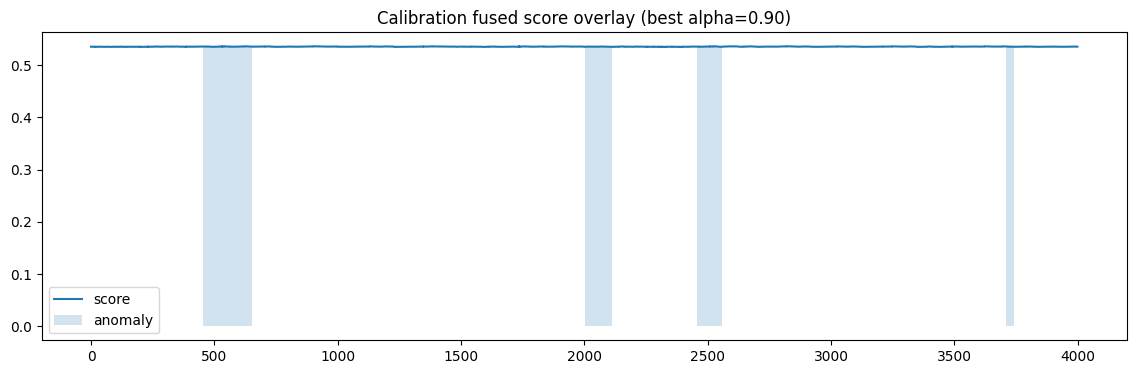

(2026-04-23 23:40:36,239) [INFO]: Register evaluations
INFO:logger:Register evaluations
(2026-04-23 23:40:36,241) [INFO]: Perform evaluations. Method[KANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
INFO:logger:Perform evaluations. Method[KANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
(2026-04-23 23:40:36,242) [INFO]:     [Load Data (All)] DataSets: MSL_HybridHoldout 
INFO:logger:    [Load Data (All)] DataSets: MSL_HybridHoldout 
(2026-04-23 23:40:36,276) [INFO]:     [KANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
INFO:logger:    [KANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
(2026-04-23 23:40:36,278) [INFO]:         [MSL_HybridHoldout] Using default margins (0, 5)
INFO:logger:        [MSL_HybridHoldout] Using default margins (0, 5)


In [10]:
# Cell 10 — Run the EasyTSAD experiment on the holdout dataset

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="MTS",
    dirname="/content/KAN-AD/datasets",
    datasets=[CUSTOM_DATASET],
)

METHOD_NAME = "KANAD_SVDD_AlphaTuned_Holdout"
TRAINING_SCHEMA = "naive"

gctrl.run_exps(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
    cfg_path=CFG_PATH,   # ✅ FIXED (use correct config)
)

gctrl.set_evals([
    PointF1PA(),
    EventF1PA(mode="squeeze"),
    PointKthF1PA(k=5),
    PointAuprcPA(),
])

gctrl.do_evals(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
)

In [11]:

# Cell 11 — Load and display EasyTSAD evaluation results

BASE_EVAL = "/content/KAN-AD/Results/Evals"
if not os.path.exists(BASE_EVAL):
    BASE_EVAL = "/content/KAN-AD/KAN-AD/Results/Evals"

avg_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "avg.json"), recursive=True)
all_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "all.json"), recursive=True)

print("Found avg.json:", avg_files)
print("Found all.json:", all_files)

assert avg_files, "avg.json not found"
assert all_files, "all.json not found"

avg_path = avg_files[0]
all_path = all_files[0]

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores = json.load(f)

print("\n=== AVERAGE RESULTS (holdout final test) ===")
for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-SERIES RESULTS ===")
print("Number of series:", len(all_scores))
if len(all_scores) > 0:
    print("Example entry:", list(all_scores.items())[0])

Found avg.json: ['/content/KAN-AD/Results/Evals/KANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/avg.json']
Found all.json: ['/content/KAN-AD/Results/Evals/KANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/all.json']

=== AVERAGE RESULTS (holdout final test) ===
best f1 under pa: {'f1': 0.8720447572640312, 'precision': 0.9265580057526366, 'recall': 0.8235895687745014, 'threshold': 0.03063511848449707}
event-based f1 under pa with mode squeeze: {'f1': 0.1999999999999998, 'precision': 0.9999999999999997, 'recall': 0.1111111111111111, 'threshold': 0.10591238737106323}
best f1 under 5-delay pa: {'f1': 0.36608594657375104, 'precision': 0.5745534086766314, 'recall': 0.2686211010738026, 'threshold': 0.025608599185943604}
point-based auprc pa: 0.904920651200908

=== PER-SERIES RESULTS ===
Number of series: 1
Example entry: ('AllInOne', {'best f1 under pa': {'f1': 0.8720447572640312, 'precision': 0.9265580057526366, 'recall': 0.8235895687745014, 'threshold': 0.03063511848449707}, 'even

In [12]:

# Cell 12 — Optional: inspect runtime stats and selected alpha

BASE_RUNTIME = "/content/KAN-AD/Results/RunTime"
if not os.path.exists(BASE_RUNTIME):
    BASE_RUNTIME = "/content/KAN-AD/KAN-AD/Results/RunTime"

runtime_files = glob.glob(
    os.path.join(BASE_RUNTIME, "**", METHOD_NAME, TRAINING_SCHEMA, CUSTOM_DATASET, "*.json"),
    recursive=True
)
print("Runtime files:", runtime_files[:5])

for fp in runtime_files[:5]:
    print("\n---", fp, "---")
    try:
        print(json.dumps(json.load(open(fp, "r")), indent=2)[:3000])
    except Exception as e:
        print("Could not read:", e)

Runtime files: ['/content/KAN-AD/Results/RunTime/KANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json']

--- /content/KAN-AD/Results/RunTime/KANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json ---
{
  "train_and_valid": 262.79029454400006,
  "test": 2.8442949000000226
}


In [13]:
# Cell 13 — Save a compact summary for thesis/report comparison

summary_row = {
    "model": METHOD_NAME,
    "dataset": CUSTOM_DATASET,
    "original_dataset": "MSL",  # ✅ FIXED
    "training_schema": TRAINING_SCHEMA,
    "config_path": CFG_PATH,   # ✅ FIXED (use actual config path)
    "window": 96,
    "order": 2,
    "lambda_svdd": 0.1,
    "emb_dim": 64,
    "calibration_dir": CALIB_DIR,
    "final_test_dir": custom_curve_dir,  # ✅ FIXED
}

# Add evaluation metrics
for k, v in avg.items():
    summary_row[k] = v

# Save with correct name
summary_path = f"/content/{METHOD_NAME}_{CUSTOM_DATASET}_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary_row, f, indent=2)

print("Saved summary to:", summary_path)

print("\nSummary row:")
for k, v in summary_row.items():
    print(f"{k}: {v}")

Saved summary to: /content/KANAD_SVDD_AlphaTuned_Holdout_MSL_HybridHoldout_summary.json

Summary row:
model: KANAD_SVDD_AlphaTuned_Holdout
dataset: MSL_HybridHoldout
original_dataset: MSL
training_schema: naive
config_path: /content/KAN-AD/kanad/config_kanad_svdd_alpha_holdout_msl.toml
window: 96
order: 2
lambda_svdd: 0.1
emb_dim: 64
calibration_dir: /content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration
final_test_dir: /content/KAN-AD/datasets/MTS/MSL_HybridHoldout/AllInOne
best f1 under pa: {'f1': 0.8720447572640312, 'precision': 0.9265580057526366, 'recall': 0.8235895687745014, 'threshold': 0.03063511848449707}
event-based f1 under pa with mode squeeze: {'f1': 0.1999999999999998, 'precision': 0.9999999999999997, 'recall': 0.1111111111111111, 'threshold': 0.10591238737106323}
best f1 under 5-delay pa: {'f1': 0.36608594657375104, 'precision': 0.5745534086766314, 'recall': 0.2686211010738026, 'threshold': 0.025608599185943604}
point-based auprc pa: 0.904920651200908


## Notes

- This notebook uses a **holdout-style evaluation**:
  - calibration from the first anomalous part of original SWaT test
  - final EasyTSAD metrics on the remaining tail only
- This avoids the failure mode you saw earlier, where **alpha tuning on a normal-only validation split always returned F1 = 0**.
- Good next refinements:
  - denser alpha grid, for example `np.linspace(0, 1, 21)`
  - stronger diagnostics for score distributions
  - replacing event-F1 calibration with delay-aware calibration